## Importing Packages and Loading Data

In [1]:
### Importing the necessary packages and data ###

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for plots

sns.set_style('whitegrid')
sns.set_palette('deep')

# Loading NHTS and NGSIM data 

nhts_data = pd.read_csv('NHTS.csv')
ngsim_data = pd.read_csv('NGSIM.csv')

#Check columns/variables included in each
#nhts_data.head()
ngsim_data.head()


,Time,leader_position(m),follower_position(m),leader_speed(m/s),follower_speed(m/s),leader_acc(m/s^2),follower_acc(m/s^2),trajectory_number
0,0.1,26.654,0.0000,14.054,14.484,1.09730,-3.048000e-02,1
1,0.2,28.060,1.4484,14.164,14.481,-1.00580,-3.048000e-02,1
2,0.3,29.476,2.8965,14.063,14.478,-2.28600,6.096000e-02,1
3,0.4,30.882,4.3443,13.835,14.484,-0.88392,-3.048000e-02,1
4,0.5,32.266,5.7927,13.746,14.481,0.85344,1.780000e-13,1


## Visualization 1 - Bar Chart
A bar chart comparing categories within a specific variable

This bar chart compares the number of vehicles in each fuel type category

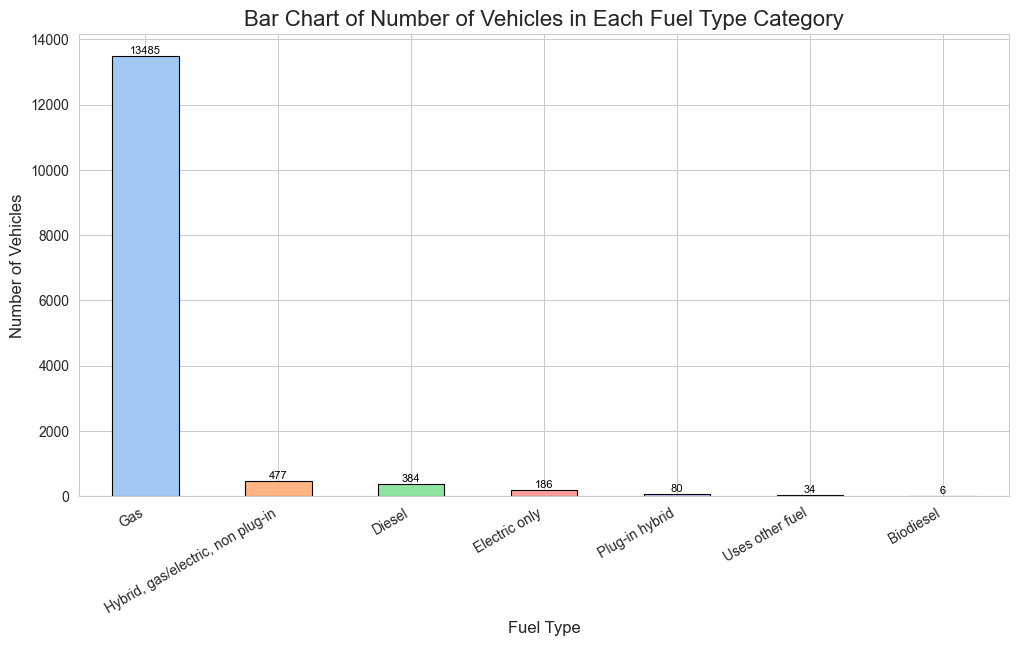

In [2]:
## Step 1: count the number of vehicles by fuel type

fuel_counts = nhts_data['fuel_type'].value_counts().dropna()

## Step 2: create the bar plot

plt.figure(figsize = (12,6))

fuel_counts.plot(kind = 'bar', color = sns.color_palette('pastel', len(fuel_counts)), edgecolor = 'black', linewidth = 0.8)

## Step 3: add labels and customization

plt.xlabel('Fuel Type',fontsize = 12) 
plt.ylabel('Number of Vehicles',fontsize = 12)
plt.xticks(rotation=30, ha='right',) #Rotates the x-axis to make it easier to read
plt.title('Bar Chart of Number of Vehicles in Each Fuel Type Category',fontsize = 16)

bar_chart = plt.gca() #plt.gca() allows access to the axes as an object
bar_chart.bar_label(bar_chart.containers[0], fontsize=8, color='black') #Adds the count number above each bar to make it easier to see

## Step 4: show the plot

plt.savefig('Bar_Chart.png', dpi = 300, bbox_inches = 'tight')
plt.show()


## Visualization 2 - Histogram
A histogram showing the distribution of a specific variable 

This histogram shows the distribution of vehicle age

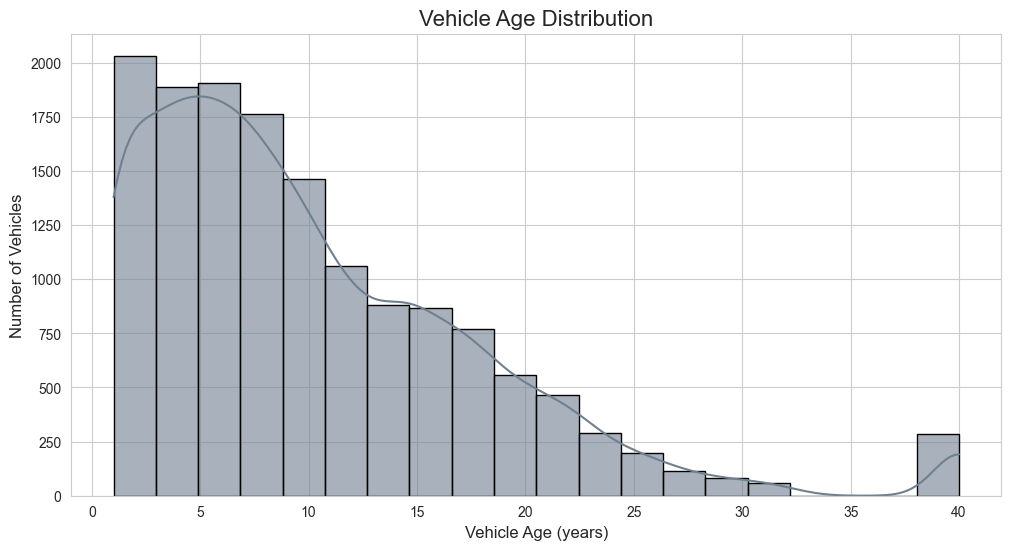

In [3]:
## Step 1: create the histogram

plt.figure(figsize=(12,6))

sns.histplot(nhts_data['vehicle_age'], bins = 20, edgecolor = 'k' , alpha = 0.6, color = 'slategray', kde = True)

## Step 2: add necessary lables

plt.xlabel('Vehicle Age (years)', fontsize = 12)
plt.ylabel('Number of Vehicles', fontsize = 12)
plt.title('Vehicle Age Distribution', fontsize = 16) 

## Step 3: show the plot

plt.savefig('Histogram.png', dpi = 300, bbox_inches = 'tight')
plt.show()


## Visualization 3 - Boxplot
A boxplot showing the distribution of a variable in each category

These boxplots show the distribution of vehicles per household grouped by urban or rural locat

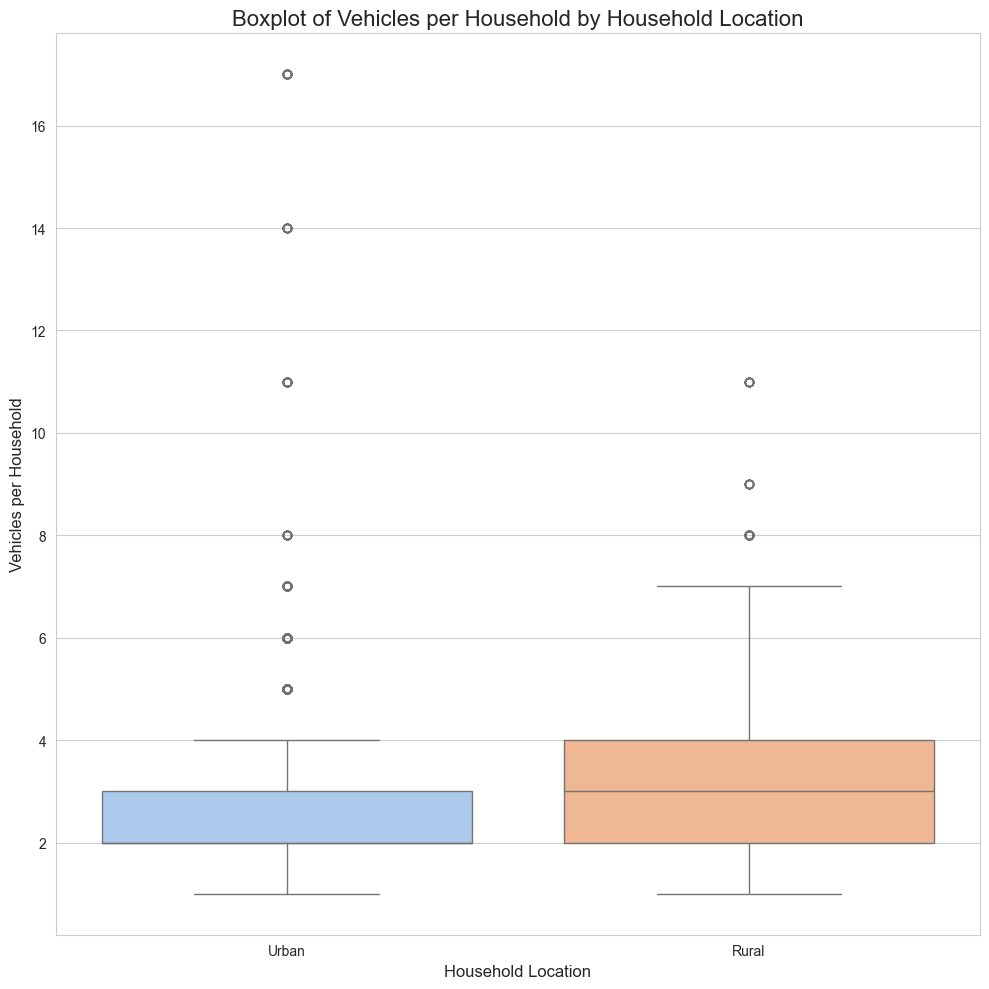

In [4]:
## Step 1: create the boxplot

plt.figure(figsize = (10,10))

sns.boxplot(data=nhts_data, x = 'household_location', y = 'vehicles_per_household', palette = 'pastel',
           hue='household_location', legend = False)

## Step 2: create lables

plt.xlabel('Household Location',fontsize = 12)
plt.ylabel('Vehicles per Household',fontsize = 12)
plt.title('Boxplot of Vehicles per Household by Household Location',fontsize = 16)

## Step 4: show the plot 

plt.tight_layout()
plt.savefig('Boxplot.png', dpi = 300, bbox_inches = 'tight')
plt.show()


## Visualization 4 - Time Series Plots
At least two different time-series plots showing and analyzing driving behavior

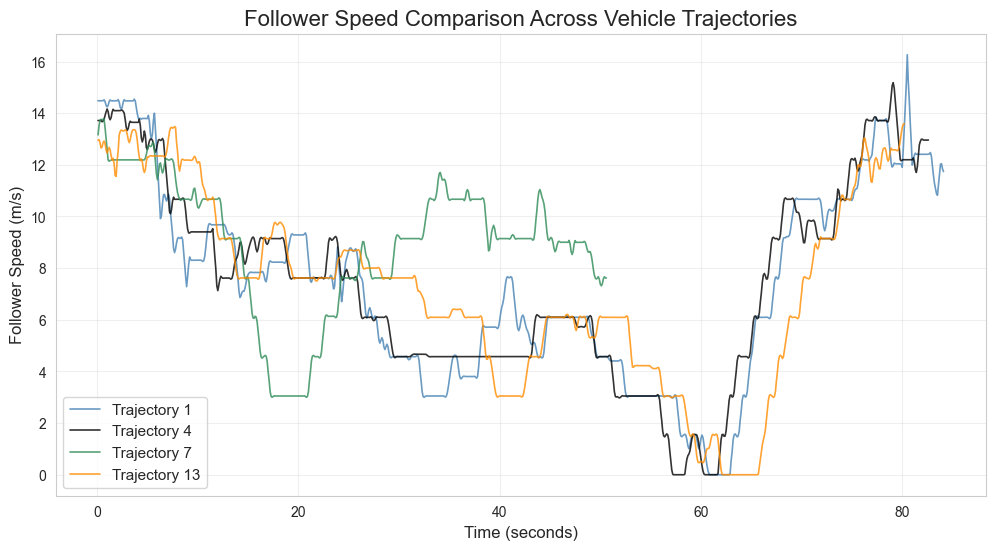

In [5]:
### Time Series Plot 1 ### 
## Step 1: Create data subset and call the trajectories to use

trajectory_numbers = [1, 4, 7, 13]
colors = ['steelblue', 'black', 'seagreen', 'darkorange'] #assigns colors to each trajectory respectively 

## Step 2: Create the figure

plt.figure(figsize = (12,6))

for traj, color in zip(trajectory_numbers, colors):
    subset = ngsim_data[ngsim_data['trajectory_number'] == traj]
    
    plt.plot(subset['Time'].values, subset['follower_speed(m/s)'].values,
             color=color, linewidth = 1.2, label = f'Trajectory {traj}', alpha = 0.8)

## Step 3: Create lables and legend 

plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Follower Speed (m/s)', fontsize = 12)
plt.title('Follower Speed Comparison Across Vehicle Trajectories', fontsize = 16)
plt.legend(fontsize = 11)
plt.grid(True, alpha = 0.3)

## Step 4: Show the plot

plt.savefig('Follower_Speed_Comparison.png', dpi = 300, bbox_inches = 'tight')
plt.show()


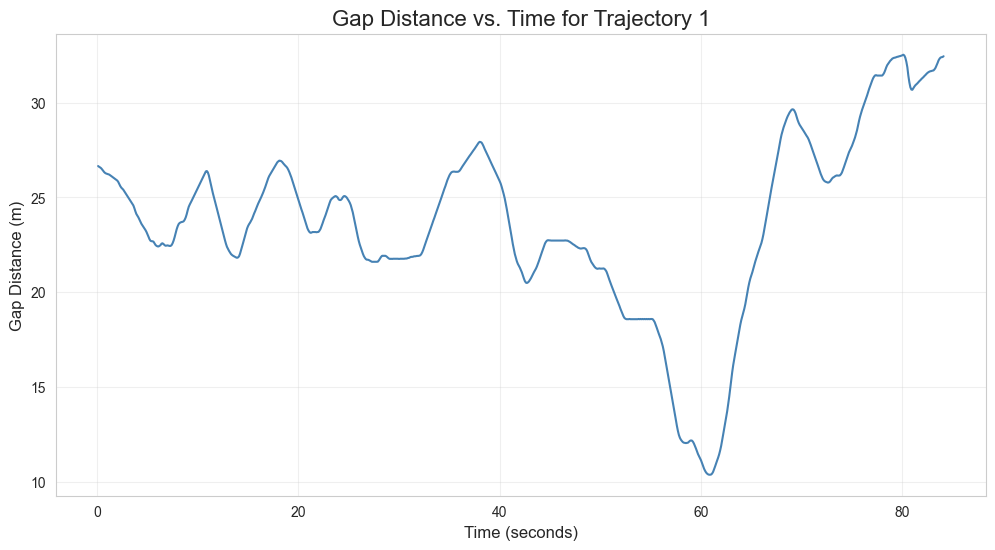

In [6]:
### Time Series Plot 2 ### 
## Step 1: Create data subset and call the trajectory to use

trajectory_number = 1
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]
gap_distance = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values

## Step 2: Create the figure 

plt.figure(figsize=(12,6))
plt.plot(data_subset['Time'], gap_distance, color = 'steelblue', linewidth=1.5)

## Step 3: Create labels 

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Gap Distance (m)', fontsize=12)
plt.title(f'Gap Distance vs. Time for Trajectory {trajectory_number}', fontsize=16)
plt.grid(True, alpha=0.3)

## Step 4: Show the plot 

plt.savefig('Gap_Distance_vs_Time.png', dpi = 300, bbox_inches = 'tight')
plt.show()


## Simulation Study 

Select a specific trajectory and simulate the follower based on the NGSIM data for the leader in the trajectory pair. 

Simulate acceleration of the follower and create a plot showing the acceleration of the leader, the follower (from NGSIM data) and the follower simulated data using the IDM model 

The IDM equations are given below. The first calculates the intsantaneous acceleration of the follower vehicle. The second calculates the desired minimum gap between the leader and follower. 

$$\frac{dv}{dt} = a \left[1 - \left(\frac{v}{v_0}\right)^\delta - \left(\frac{s^*(v, \Delta v)}{s}\right)^2\right]$$

$$s^*(v, \Delta v) = s_0 + v \cdot T + \frac{v \cdot \Delta v}{2\sqrt{a \cdot b}}$$

The parameters used in the equations are summarized below. Typical values are given which will be held as constants in the equations. 

The only variables changeing are:
- v - current speed of follower vehicle
- s - the current gap distance between the leader and the follower
- delta_v - the speed difference between the follower and leader.

| Parameter | Symbol | Description | Typical Value |
|-----------|--------|-------------|---------------|
| Desired velocity | $v_0$ | Speed the driver wants to travel at in free flow | 30 m/s |
| Minimum spacing | $s_0$ | Minimum gap between vehicles when stopped | 2 m |
| Desired time headway | $T$ | Desired time gap to the leader | 1.5 s |
| Maximum acceleration | $a$ | Maximum comfortable acceleration | 1.0 m/s² |
| Comfortable deceleration | $b$ | Comfortable braking deceleration | 1.5 m/s² |
| Acceleration exponent | $\delta$ | Controls how acceleration decreases with speed | 4 |


In [7]:
# Define IDM variables and inputs

#   v       : current speed of the follower vehicle (m/s)
#   s       : current gap distance between leader and follower (m)
#   delta_v : speed difference = follower speed - leader speed (m/s)
#   v0      : desired velocity (m/s)
#   s0      : minimum spacing (m)
#   T       : desired time headway (s)
#   a_max   : maximum acceleration (m/s^2)
#   b       : comfortable deceleration (m/s^2)
#   delta   : acceleration exponent

# Constants are defined below

v0 = 30 
s0 = 2 
T = 1.5 
a_max = 1.0 
b = 1.5 
delta = 4 

# Step 2: Define the IDM function

def idm_acceleration(v, s, delta_v, v0, s0, T, a_max, b, delta):
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a_max * b))  # Calculate the desired minimum gap s_star
    s_star = max(s_star, s0)                                        # Make sure s_star is not negative
    acceleration = a_max * (1 - (v/v0)**delta - (s_star/s)**2)          # Calculate the acceleration using the IDM equation
    return acceleration


In [8]:
# Setting up the simulation 

# Pick a trajectory pair 

trajectory_number = 2

# Extract variables from the dataset according to trajectory number

data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop=True)
leader_position = data_subset['leader_position(m)'].values 
leader_speed = data_subset['leader_speed(m/s)'].values
time_data = data_subset['Time'].values 

# Identify the time step in the trajectory (dt)
dt = time_data[1] - time_data[0]


In [9]:
# Running the simulation 

# Initialize arrays to store simulation results

n_steps = len(time_data)           # number of simulation steps we will take, which will be equal to the length of the trajectory data
sim_position = np.zeros(n_steps)   # simulated follower position; we will create a vector with all zeroes  as a startsim
sim_speed = np.zeros(n_steps)      # simulated follower speed; we will create a vector with all zeroes  as a start
sim_acc = np.zeros(n_steps)        # simulated follower acceleration; we will create a vector with all zeroes  as a start

# Start at the real follower's initial state
sim_position[0] = data_subset['follower_position(m)'].values[0] #this makes the starting value [0] same as the follower vehicle position
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]     #this makes the starting value [0] same as the follower vehicle speed

# Looping through each time step

for i in range(n_steps - 1):                              # we do -1 since the first element is known (remember the step above) 
    gap = max(leader_position[i] - sim_position[i], 0.1)  # just a condition to make gap positive
    delta_v = sim_speed[i] - leader_speed[i]
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a_max, b, delta) 
    
    # Update speed and position for the next time step in the loop 

    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i] * dt, 0) # updates speed for next iteration based on physics equation of motion
    sim_position[i+1] = sim_position[i] + sim_speed[i] * dt
print("Simulation complete!")



Simulation complete!


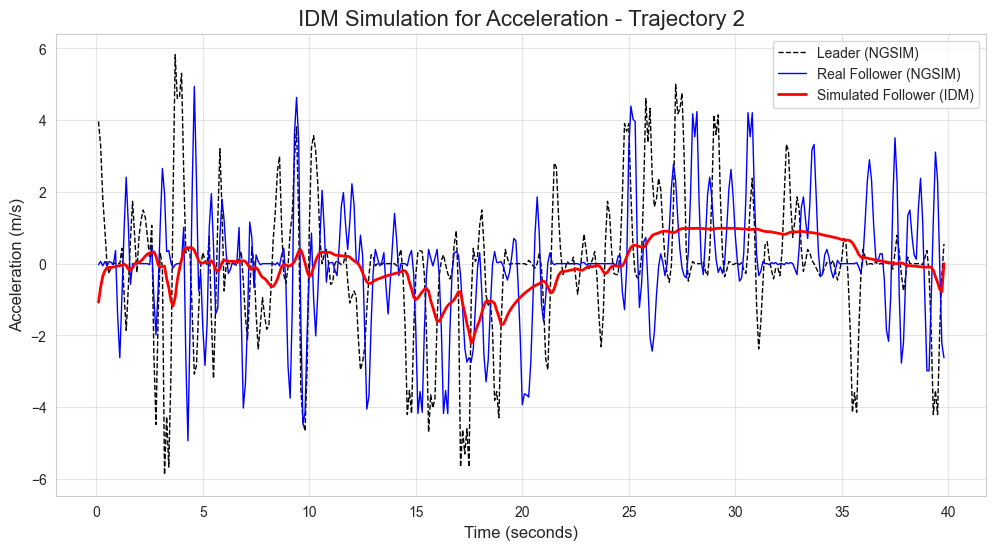

In [10]:
# Create visualization of leader acceleration, follower acceleration, and simulated acceleration.

plt.figure(figsize=(12,6))
plt.plot(time_data, data_subset['leader_acc(m/s^2)'].values, 'k--', linewidth = 1, label = 'Leader (NGSIM)')
plt.plot(time_data, data_subset['follower_acc(m/s^2)'].values, 'b-', linewidth = 1, label = 'Real Follower (NGSIM)')
plt.plot(time_data, sim_acc, 'r-', linewidth = 2, label = 'Simulated Follower (IDM)')

plt.xlabel('Time (seconds)', fontsize = 12) 
plt.ylabel('Acceleration (m/s)', fontsize = 12)
plt.title(f'IDM Simulation for Acceleration - Trajectory {trajectory_number}', fontsize = 16)
plt.legend()
plt.grid(True, alpha = 0.5) 
plt.savefig('IDM_Simulation_ACCELERATION', dpi = 300, bbox_inches = 'tight')
plt.show()
